# 🛒 E-COMMERCE DATA - KAPSAMLI DATA SCIENCE & BUSINESS ANALİZİ
## Wget ile Kaggle Dataset İndirme + E-Commerce Özel Analizler

---

**Dataset Kaynağı:** https://www.kaggle.com/datasets/carrie1/ecommerce-data

**Analiz İçeriği:**
- ✅ Wget ile direkt Kaggle indirme
- ✅ Comprehensive Data Exploration
- ✅ E-Commerce Specific Analysis
- ✅ RFM Analysis (Recency, Frequency, Monetary)
- ✅ Cohort Analysis
- ✅ Market Basket Analysis
- ✅ Customer Segmentation
- ✅ Time Series Analysis
- ✅ Product Performance Analysis
- ✅ Geographic Analysis
- ✅ Machine Learning (Customer Churn, CLV Prediction)
- ✅ Business Insights & Recommendations

---

## 📥 1. DATASET İNDİRME (WGET İLE DİREKT İNDİRME)

In [1]:
import os
import subprocess
import zipfile
import glob
from pathlib import Path

def download_dataset_direct(download_url, dest_folder, zip_filename):
    """
    Belirtilen URL'den wget ile veri seti zip dosyasını indirir.
    """
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{'='*80}")
    print(f"📥 {zip_filename} indiriliyor...")
    print(f"🔗 URL: {download_url}")
    print(f"{'='*80}")
    print("\n⏳ Bu işlem birkaç dakika sürebilir...\n")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\n✅ {zip_filename} başarıyla indirildi!")
        print(f"📂 Konum: {full_zip_path}")
        return True
    except Exception as e:
        print(f"\n❌ İndirme hatası: {e}")
        return False

def extract_dataset(dest_folder):
    """İndirilen zip dosyasını açar ve temizler"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"⚠️ {dest_folder} klasöründe zip dosyası bulunamadı")
            return False

        print(f"\n{'='*80}")
        print("📦 ZIP DOSYASI AÇILIYOR")
        print(f"{'='*80}\n")

        for zip_file in zip_files:
            print(f"📦 Açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                # Dosya listesini göster
                file_list = zip_ref.namelist()
                print(f"📋 İçindeki dosyalar ({len(file_list)}):")
                for f in file_list[:5]:  # İlk 5 dosyayı göster
                    print(f"   - {f}")
                if len(file_list) > 5:
                    print(f"   ... ve {len(file_list)-5} dosya daha")

                zip_ref.extractall(dest_folder)

            # Zip dosyasını sil
            os.remove(zip_file)
            print(f"\n✅ Zip dosyası açıldı ve silindi (disk alanı tasarrufu)")

        print(f"\n🎉 Dataset başarıyla hazır!")
        return True
    except Exception as e:
        print(f"\n❌ Zip açma hatası: {e}")
        return False

# Ana klasörü oluştur
dataset_folder = "ecommerce_dataset"
if not os.path.exists(dataset_folder):
    os.makedirs(dataset_folder)
    print(f"📁 Klasör oluşturuldu: {dataset_folder}")

# E-Commerce Dataset bilgileri
ecommerce_dataset_info = {
    "name": "ecommerce-data",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/carrie1/ecommerce-data",
    "folder": dataset_folder,
    "zip_filename": "ecommerce-data.zip"
}

# CSV dosyası var mı kontrol et
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    print("\n" + "="*80)
    print("✅ Dataset zaten mevcut, indirme atlanıyor...")
    print("="*80)
    dataset_path = csv_files[0]
    print(f"\n📂 Dataset dosyası: {dataset_path}")
    print(f"📊 Dosya boyutu: {os.path.getsize(dataset_path) / 1024**2:.2f} MB")
else:
    # İndirme işlemi
    print("\n" + "="*80)
    print("🚀 E-COMMERCE DATASET İNDİRİLİYOR")
    print("="*80)

    download_success = download_dataset_direct(
        ecommerce_dataset_info["download_url"],
        ecommerce_dataset_info["folder"],
        ecommerce_dataset_info["zip_filename"]
    )

    if download_success:
        # Zip dosyasını aç
        extract_dataset(ecommerce_dataset_info["folder"])

        # CSV dosyasını bul
        csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))
        if csv_files:
            dataset_path = csv_files[0]
            print(f"\n✅ Dataset hazır: {dataset_path}")
            print(f"📊 Dosya boyutu: {os.path.getsize(dataset_path) / 1024**2:.2f} MB")
        else:
            print("\n❌ CSV dosyası bulunamadı!")
    else:
        print("\n" + "="*80)
        print("❌ İNDİRME BAŞARISIZ!")
        print("="*80)
        print("\n📋 MANUEL İNDİRME TALİMATLARI:")
        print("1. https://www.kaggle.com/datasets/carrie1/ecommerce-data adresine gidin")
        print("2. 'Download' butonuna tıklayın (Kaggle hesabı gerekli)")
        print(f"3. İndirilen zip dosyasını '{dataset_folder}/' klasörüne yerleştirin")
        print("4. Bu notebook'u tekrar çalıştırın")
        print("\n💡 NOT: Kaggle API kullanmak için:")
        print("   - Kaggle hesabınızdan API token indirin")
        print("   - ~/.kaggle/kaggle.json dosyasına yerleştirin")

📁 Klasör oluşturuldu: ecommerce_dataset

🚀 E-COMMERCE DATASET İNDİRİLİYOR

📥 ecommerce-data.zip indiriliyor...
🔗 URL: https://www.kaggle.com/api/v1/datasets/download/carrie1/ecommerce-data

⏳ Bu işlem birkaç dakika sürebilir...


✅ ecommerce-data.zip başarıyla indirildi!
📂 Konum: ecommerce_dataset/ecommerce-data.zip

📦 ZIP DOSYASI AÇILIYOR

📦 Açılıyor: ecommerce_dataset/ecommerce-data.zip
📋 İçindeki dosyalar (1):
   - data.csv

✅ Zip dosyası açıldı ve silindi (disk alanı tasarrufu)

🎉 Dataset başarıyla hazır!

✅ Dataset hazır: ecommerce_dataset/data.csv
📊 Dosya boyutu: 43.47 MB


## 📚 2. KÜTÜPHANELERİ YÜKLE

In [2]:
# Data manipulation & analysis
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from collections import Counter
import itertools

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import (
    normaltest, shapiro, kstest,
    chi2_contingency, pearsonr,
    spearmanr
)

# Machine Learning
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder,
    MinMaxScaler
)
from sklearn.linear_model import (
    LinearRegression, LogisticRegression
)
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Random seed
np.random.seed(42)

print("="*80)
print("✅ TÜM KÜTÜPHANELER BAŞARIYLA YÜKLENDİ!")
print("="*80)
print(f"\n📦 Versiyon Bilgileri:")
print(f"   🐍 Python: {__import__('sys').version.split()[0]}")
print(f"   📊 Pandas: {pd.__version__}")
print(f"   🔢 NumPy: {np.__version__}")
print(f"   📈 Matplotlib: {plt.matplotlib.__version__}")
print(f"   🎨 Seaborn: {sns.__version__}")
print(f"   🤖 Scikit-learn: {__import__('sklearn').__version__}")
print(f"\n🎯 Hazır: E-Commerce Data Science Analysis!")

✅ TÜM KÜTÜPHANELER BAŞARIYLA YÜKLENDİ!

📦 Versiyon Bilgileri:
   🐍 Python: 3.12.12
   📊 Pandas: 2.2.2
   🔢 NumPy: 2.0.2
   📈 Matplotlib: 3.10.0
   🎨 Seaborn: 0.13.2
   🤖 Scikit-learn: 1.6.1

🎯 Hazır: E-Commerce Data Science Analysis!


## 📊 3. VERİYİ YÜKLE VE İLK KEŞİF

In [3]:
# CSV dosyasını bul ve yükle
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    print("❌ CSV dosyası bulunamadı! Lütfen önce dataset'i indirin.")
    raise FileNotFoundError("Dataset CSV dosyası bulunamadı!")
else:
    dataset_path = csv_files[0]
    print(f"{'='*80}")
    print("📂 DATASET YÜKLEME")
    print(f"{'='*80}")
    print(f"\n📄 Dosya: {dataset_path}")
    print(f"📊 Boyut: {os.path.getsize(dataset_path) / 1024**2:.2f} MB")
    print(f"\n⏳ Yükleniyor...\n")

    # Veriyi yükle (encoding issues için)
    try:
        df = pd.read_csv(dataset_path, encoding='ISO-8859-1')
    except:
        df = pd.read_csv(dataset_path, encoding='utf-8')

    print("✅ Dataset başarıyla yüklendi!\n")

    print(f"{'='*80}")
    print("📊 DATASET GENEL BİLGİLERİ")
    print(f"{'='*80}")
    print(f"\n📌 Toplam Satır (Transaction): {df.shape[0]:,}")
    print(f"📌 Toplam Sütun: {df.shape[1]}")
    print(f"📌 Toplam Veri Noktası: {df.shape[0] * df.shape[1]:,}")
    print(f"📌 Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print(f"\n{'='*80}")
    print("📋 SÜTUN LİSTESİ VE TİPLERİ")
    print(f"{'='*80}")
    for i, col in enumerate(df.columns, 1):
        dtype = df[col].dtype
        null_count = df[col].isnull().sum()
        null_pct = (null_count / len(df) * 100)
        print(f"{i:2d}. {col:20s} | Type: {str(dtype):10s} | Nulls: {null_count:8,} ({null_pct:5.2f}%)")

📂 DATASET YÜKLEME

📄 Dosya: ecommerce_dataset/data.csv
📊 Boyut: 43.47 MB

⏳ Yükleniyor...

✅ Dataset başarıyla yüklendi!

📊 DATASET GENEL BİLGİLERİ

📌 Toplam Satır (Transaction): 541,909
📌 Toplam Sütun: 8
📌 Toplam Veri Noktası: 4,335,272
📌 Bellek Kullanımı: 173.12 MB

📋 SÜTUN LİSTESİ VE TİPLERİ
 1. InvoiceNo            | Type: object     | Nulls:        0 ( 0.00%)
 2. StockCode            | Type: object     | Nulls:        0 ( 0.00%)
 3. Description          | Type: object     | Nulls:    1,454 ( 0.27%)
 4. Quantity             | Type: int64      | Nulls:        0 ( 0.00%)
 5. InvoiceDate          | Type: object     | Nulls:        0 ( 0.00%)
 6. UnitPrice            | Type: float64    | Nulls:        0 ( 0.00%)
 7. CustomerID           | Type: float64    | Nulls:  135,080 (24.93%)
 8. Country              | Type: object     | Nulls:        0 ( 0.00%)


In [4]:
# İlk bakış
print(f"\n{'='*80}")
print("👀 İLK 10 SATIR - DATASET ÖRNEKLERİ")
print(f"{'='*80}\n")
display(df.head(10))


👀 İLK 10 SATIR - DATASET ÖRNEKLERİ



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.00,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.00,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.00,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.00,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.00,United Kingdom


In [5]:
# Son satırlar
print(f"\n{'='*80}")
print("👀 SON 10 SATIR")
print(f"{'='*80}\n")
display(df.tail(10))


👀 SON 10 SATIR



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,12/9/2011 12:50,3.75,12680.00,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,12/9/2011 12:50,3.75,12680.00,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,12/9/2011 12:50,1.95,12680.00,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,12/9/2011 12:50,1.95,12680.00,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,12/9/2011 12:50,4.15,12680.00,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.00,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.00,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.00,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.00,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.00,France


In [6]:
# Random örnekler
print(f"\n{'='*80}")
print("🎲 RASTGELE 10 SATIR")
print(f"{'='*80}\n")
display(df.sample(10))


🎲 RASTGELE 10 SATIR



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,6/1/2011 12:05,0.85,17315.00,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,5/27/2011 17:14,6.95,14031.00,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,4/21/2011 17:05,0.65,14031.00,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,11/16/2011 10:39,1.95,17198.00,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,3/10/2011 8:40,9.95,13502.00,United Kingdom
465024,576200,82482,WOODEN PICTURE FRAME WHITE FINISH,2,11/14/2011 12:14,2.95,15572.00,United Kingdom
477777,577076,22614,PACK OF 12 SPACEBOY TISSUES,12,11/17/2011 15:08,0.39,14362.00,United Kingdom
367855,568909,22596,CHRISTMAS STAR WISH LIST CHALKBOARD,12,9/29/2011 13:38,1.25,16818.00,United Kingdom
491657,578072,21109,LARGE CAKE TOWEL CHOCOLATE SPOTS,1,11/22/2011 16:02,6.75,17759.00,United Kingdom
269641,560491,23297,SET 40 HEART SHAPE PETIT FOUR CASES,2,7/19/2011 10:51,1.65,12415.00,Australia


In [7]:
# Dataset detaylı bilgi
print(f"\n{'='*80}")
print("ℹ️ DATASET DETAYLI BİLGİLERİ")
print(f"{'='*80}\n")
df.info()


ℹ️ DATASET DETAYLI BİLGİLERİ

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
# Sütunların unique değerleri
print(f"\n{'='*80}")
print("🔍 UNIQUE DEĞER ANALİZİ")
print(f"{'='*80}\n")

unique_analysis = pd.DataFrame({
    'Sütun': df.columns,
    'Unique_Sayısı': [df[col].nunique() for col in df.columns],
    'Örnek_Değerler': [str(df[col].unique()[:3].tolist()) for col in df.columns]
})

print(unique_analysis.to_string(index=False))


🔍 UNIQUE DEĞER ANALİZİ

      Sütun  Unique_Sayısı                                                                                  Örnek_Değerler
  InvoiceNo          25900                                                                  ['536365', '536366', '536367']
  StockCode           4070                                                                   ['85123A', '71053', '84406B']
Description           4223 ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER']
   Quantity            722                                                                                       [6, 8, 2]
InvoiceDate          23260                                          ['12/1/2010 8:26', '12/1/2010 8:28', '12/1/2010 8:34']
  UnitPrice           1630                                                                              [2.55, 3.39, 2.75]
 CustomerID           4372                                                                     [17850.0, 13047.0, 

## 🔍 4. EKSİK DEĞER VE VERİ KALİTESİ ANALİZİ

🔍 EKSİK DEĞER ANALİZİ

      Sütun  Eksik_Sayısı  Eksik_Yüzdesi Veri_Tipi  Dolu_Sayısı
 CustomerID        135080          24.93   float64       406829
Description          1454           0.27    object       540455
  StockCode             0           0.00    object       541909
  InvoiceNo             0           0.00    object       541909
   Quantity             0           0.00     int64       541909
InvoiceDate             0           0.00    object       541909
  UnitPrice             0           0.00   float64       541909
    Country             0           0.00    object       541909

⚠️ 2 sütunda eksik değer var!



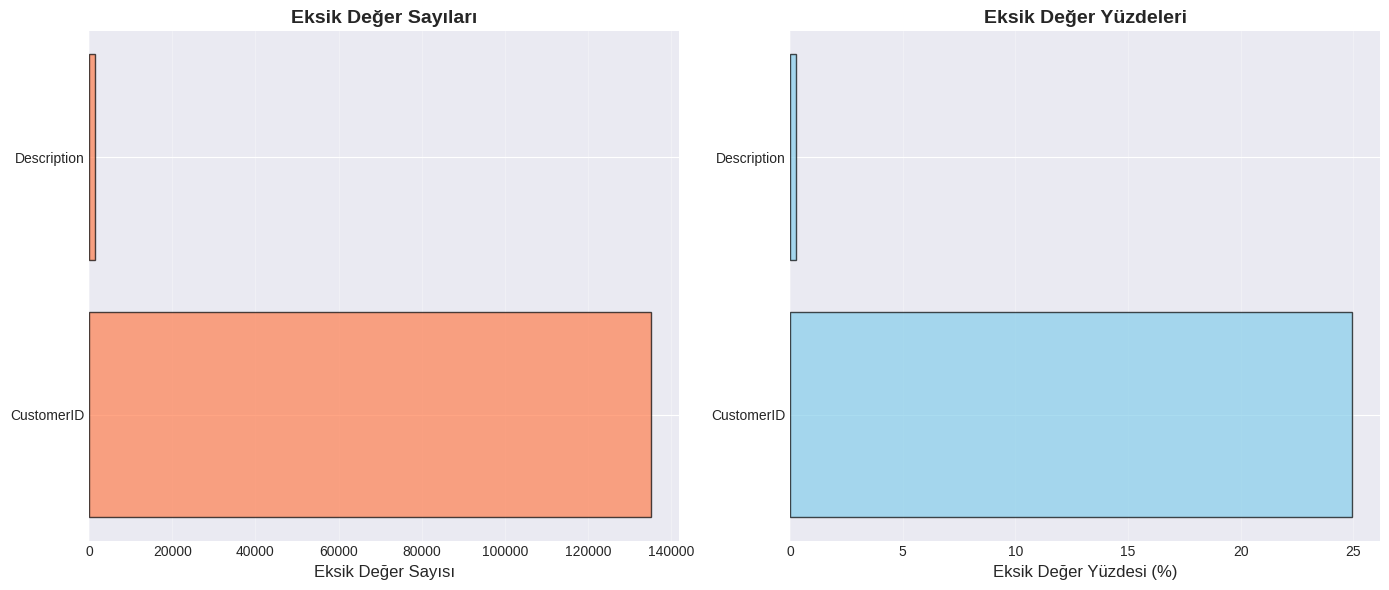


📊 Toplam Eksik Değer: 136,534
📊 Genel Eksik Oran: 3.15%


In [9]:
print(f"{'='*80}")
print("🔍 EKSİK DEĞER ANALİZİ")
print(f"{'='*80}\n")

# Eksik değer istatistikleri
missing_stats = pd.DataFrame({
    'Sütun': df.columns,
    'Eksik_Sayısı': df.isnull().sum(),
    'Eksik_Yüzdesi': (df.isnull().sum() / len(df) * 100).round(2),
    'Veri_Tipi': df.dtypes,
    'Dolu_Sayısı': df.count()
}).sort_values('Eksik_Sayısı', ascending=False)

print(missing_stats.to_string(index=False))

# Eksik değer görselleştirme
missing_stats_filtered = missing_stats[missing_stats['Eksik_Sayısı'] > 0]

if len(missing_stats_filtered) > 0:
    print(f"\n⚠️ {len(missing_stats_filtered)} sütunda eksik değer var!\n")

    plt.figure(figsize=(14, 6))

    # Bar chart
    plt.subplot(1, 2, 1)
    plt.barh(missing_stats_filtered['Sütun'], missing_stats_filtered['Eksik_Sayısı'],
             color='coral', edgecolor='black', alpha=0.7)
    plt.xlabel('Eksik Değer Sayısı', fontsize=12)
    plt.title('Eksik Değer Sayıları', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')

    # Percentage chart
    plt.subplot(1, 2, 2)
    plt.barh(missing_stats_filtered['Sütun'], missing_stats_filtered['Eksik_Yüzdesi'],
             color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Eksik Değer Yüzdesi (%)', fontsize=12)
    plt.title('Eksik Değer Yüzdeleri', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Toplam Eksik Değer: {df.isnull().sum().sum():,}")
    print(f"📊 Genel Eksik Oran: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")
else:
    print("\n✅ Hiçbir sütunda eksik değer yok!")

In [10]:
# Duplicate analizi
print(f"\n{'='*80}")
print("🔍 DUPLICATE (TEKRAR EDEN) SATIR ANALİZİ")
print(f"{'='*80}\n")

duplicates = df.duplicated().sum()
print(f"📌 Tam Duplicate Satır Sayısı: {duplicates:,}")
print(f"📌 Duplicate Yüzdesi: {(duplicates/len(df)*100):.2f}%")

if duplicates > 0:
    print(f"\n⚠️ {duplicates:,} adet duplicate satır tespit edildi!")
    print("\n📋 İlk 5 Duplicate Satır:")
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
    display(duplicate_rows.head(5))
else:
    print("\n✅ Hiç duplicate satır yok!")


🔍 DUPLICATE (TEKRAR EDEN) SATIR ANALİZİ

📌 Tam Duplicate Satır Sayısı: 5,268
📌 Duplicate Yüzdesi: 0.97%

⚠️ 5,268 adet duplicate satır tespit edildi!

📋 İlk 5 Duplicate Satır:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.00,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.00,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.00,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.00,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.00,United Kingdom


## 🧹 5. VERİ TEMİZLEME VE ÖNİŞLEME

In [11]:
print(f"{'='*80}")
print("🧹 VERİ TEMİZLEME VE ÖNİŞLEME")
print(f"{'='*80}\n")

# Orijinal boyut
original_shape = df.shape
print(f"📌 Başlangıç: {original_shape[0]:,} satır x {original_shape[1]} sütun\n")

# DataFrame kopyasını al
df_clean = df.copy()

# 1. Sütun isimlerini standartlaştır
df_clean.columns = df_clean.columns.str.strip()
print("✅ Sütun isimleri temizlendi")

# 2. Duplicate satırları kaldır
if df_clean.duplicated().sum() > 0:
    before_dup = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    print(f"✅ {before_dup - len(df_clean):,} duplicate satır kaldırıldı")

# 3. Tarih sütunlarını datetime'a çevir
date_columns = [col for col in df_clean.columns if 'date' in col.lower() or 'time' in col.lower()]
if date_columns:
    for col in date_columns:
        try:
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
            print(f"✅ {col} → datetime'a çevrildi")
        except:
            print(f"⚠️ {col} → datetime'a çevrilemedi")

# 4. Negatif quantity ve price değerlerini kontrol et (E-commerce için önemli)
if 'Quantity' in df_clean.columns:
    negative_qty = (df_clean['Quantity'] < 0).sum()
    if negative_qty > 0:
        print(f"⚠️ {negative_qty:,} negatif Quantity değeri bulundu (iadeler olabilir)")

if 'UnitPrice' in df_clean.columns:
    negative_price = (df_clean['UnitPrice'] < 0).sum()
    zero_price = (df_clean['UnitPrice'] == 0).sum()
    if negative_price > 0:
        print(f"⚠️ {negative_price:,} negatif UnitPrice değeri bulundu")
    if zero_price > 0:
        print(f"⚠️ {zero_price:,} sıfır UnitPrice değeri bulundu")

# 5. Eksik değerleri analiz et ve doldur
print(f"\n📊 Eksik Değer İşleme Stratejisi:")
print("-" * 80)

for col in df_clean.columns:
    missing_count = df_clean[col].isnull().sum()

    if missing_count > 0:
        missing_pct = (missing_count / len(df_clean)) * 100

        # Çok fazla eksik varsa sütunu kaldır
        if missing_pct > 50:
            df_clean = df_clean.drop(columns=[col])
            print(f"  ❌ {col}: %{missing_pct:.1f} eksik → Sütun kaldırıldı")

        # CustomerID için özel işlem (E-commerce'de önemli)
        elif 'customer' in col.lower():
            # CustomerID eksik olanları işaretleyebiliriz
            print(f"  ⚠️ {col}: {missing_count:,} eksik değer → Korundu (analiz edilecek)")

        # Description için mode
        elif 'description' in col.lower():
            if not df_clean[col].mode().empty:
                df_clean[col].fillna('Unknown', inplace=True)
                print(f"  ✅ {col}: {missing_count:,} eksik → 'Unknown' ile dolduruldu")

# 6. TotalAmount sütunu oluştur (varsa)
if 'Quantity' in df_clean.columns and 'UnitPrice' in df_clean.columns:
    df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']
    print(f"\n✅ TotalAmount sütunu oluşturuldu (Quantity × UnitPrice)")

# Final durum
final_shape = df_clean.shape
print(f"\n{'='*80}")
print(f"📌 Temizlenmiş: {final_shape[0]:,} satır x {final_shape[1]} sütun")
print(f"📌 Silinen Satır: {original_shape[0] - final_shape[0]:,}")
print(f"📌 Kalan Eksik: {df_clean.isnull().sum().sum():,}")
print(f"📌 Bellek: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"{'='*80}")

# Temizlenmiş veriyi ana değişkene ata
df = df_clean.copy()
print("\n✅ VERİ TEMİZLEME TAMAMLANDI!")

🧹 VERİ TEMİZLEME VE ÖNİŞLEME

📌 Başlangıç: 541,909 satır x 8 sütun

✅ Sütun isimleri temizlendi
✅ 5,268 duplicate satır kaldırıldı
✅ InvoiceDate → datetime'a çevrildi
⚠️ 10,587 negatif Quantity değeri bulundu (iadeler olabilir)
⚠️ 2 negatif UnitPrice değeri bulundu
⚠️ 2,510 sıfır UnitPrice değeri bulundu

📊 Eksik Değer İşleme Stratejisi:
--------------------------------------------------------------------------------
  ✅ Description: 1,454 eksik → 'Unknown' ile dolduruldu
  ⚠️ CustomerID: 135,037 eksik değer → Korundu (analiz edilecek)

✅ TotalAmount sütunu oluşturuldu (Quantity × UnitPrice)

📌 Temizlenmiş: 536,641 satır x 9 sütun
📌 Silinen Satır: 5,268
📌 Kalan Eksik: 135,037
📌 Bellek: 151.01 MB

✅ VERİ TEMİZLEME TAMAMLANDI!


## 📊 6. TANIMLAYICI İSTATİSTİKLER VE EDA

📊 SAYISAL DEĞİŞKENLER - İSTATİSTİKLER



,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,range
Quantity,536641.00,9.62,219.13,-80995.00,1.00,3.00,10.00,80995.00,48018.03,-0.26,118645.54,161990.00
UnitPrice,536641.00,4.63,97.23,-11062.06,1.25,2.08,4.13,38970.00,9454.28,185.60,58433.14,50032.06
CustomerID,401604.00,15281.16,1714.01,12346.00,13939.00,15145.00,16784.00,18287.00,2937816.87,0.03,-1.18,5941.00
TotalAmount,536641.00,18.12,380.66,-168469.60,3.75,9.87,17.40,168469.60,144899.19,-0.96,149742.86,336939.20


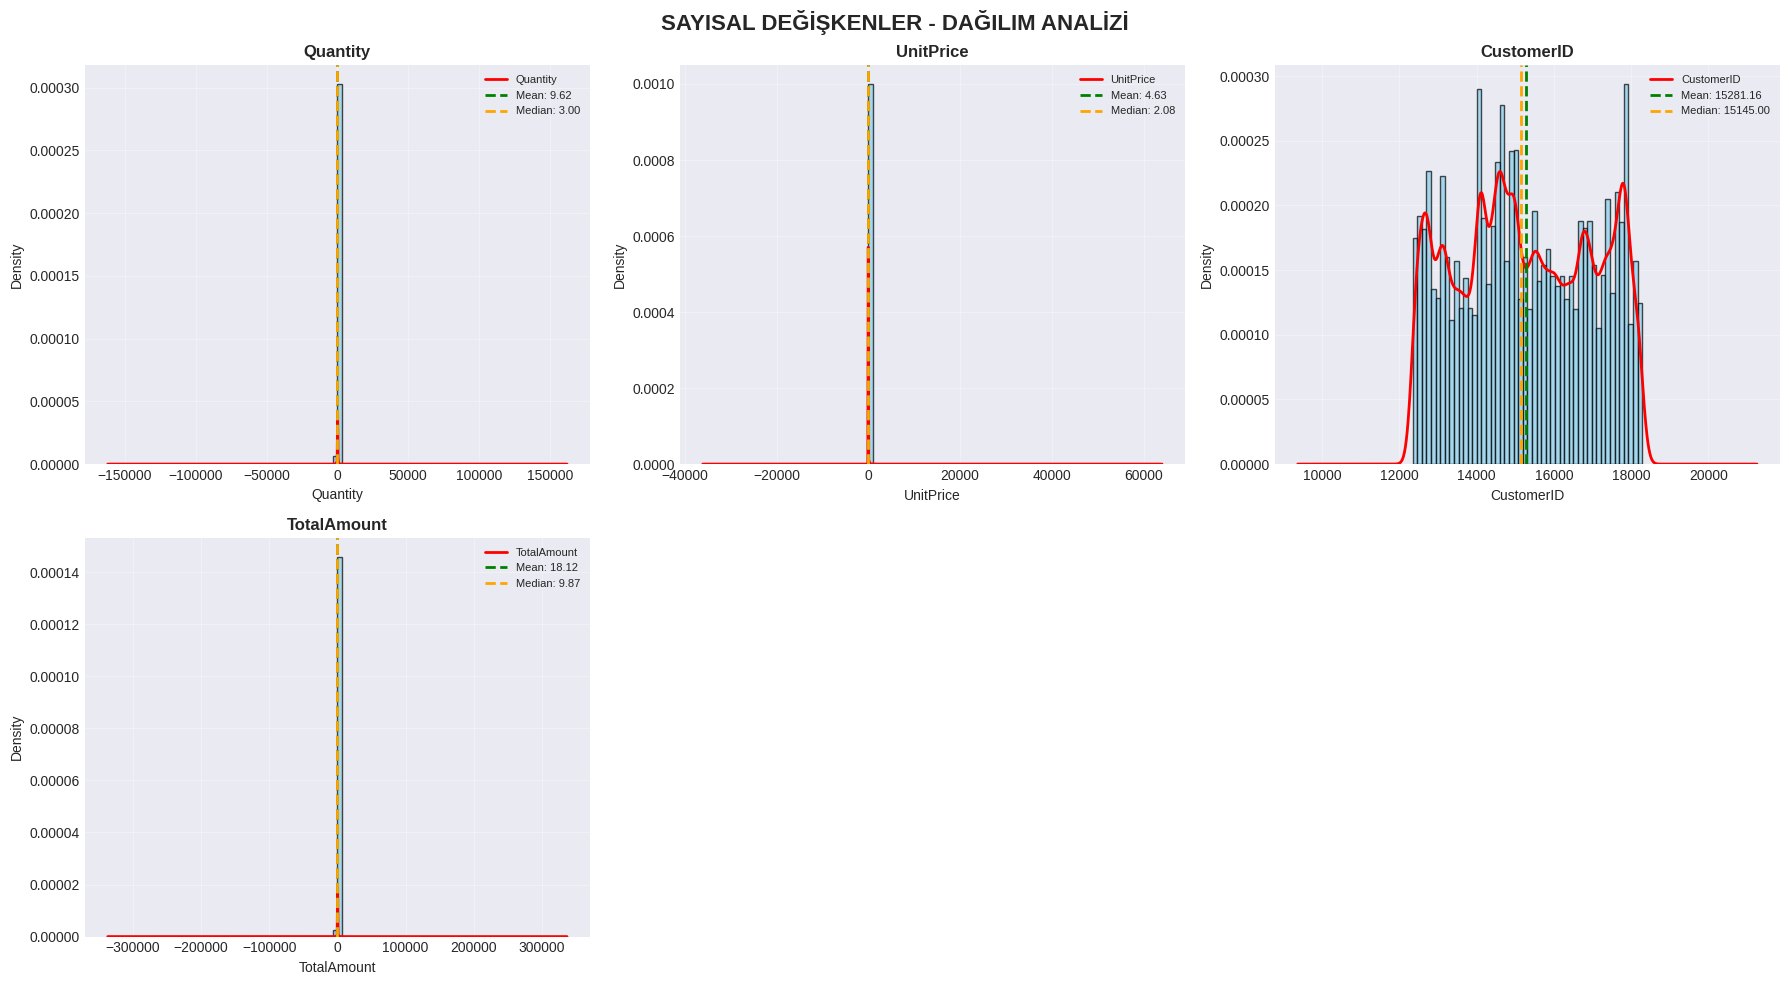

In [12]:
print(f"{'='*80}")
print("📊 SAYISAL DEĞİŞKENLER - İSTATİSTİKLER")
print(f"{'='*80}\n")

# Sayısal sütunlar
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    # Temel istatistikler
    stats_df = df[numeric_cols].describe().T

    # Ek istatistikler
    stats_df['variance'] = df[numeric_cols].var()
    stats_df['skewness'] = df[numeric_cols].skew()
    stats_df['kurtosis'] = df[numeric_cols].kurtosis()
    stats_df['range'] = df[numeric_cols].max() - df[numeric_cols].min()

    display(stats_df)

    # Distribution plots
    n_cols = min(len(numeric_cols), 6)
    cols_to_plot = numeric_cols[:n_cols]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('SAYISAL DEĞİŞKENLER - DAĞILIM ANALİZİ', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for idx, col in enumerate(cols_to_plot):
        data = df[col].dropna()

        # Histogram + KDE
        axes[idx].hist(data, bins=50, color='skyblue', edgecolor='black',
                      alpha=0.7, density=True)
        data.plot(kind='kde', ax=axes[idx], color='red', linewidth=2)

        # İstatistikler
        mean_val = data.mean()
        median_val = data.median()

        axes[idx].axvline(mean_val, color='green', linestyle='--', linewidth=2,
                         label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='orange', linestyle='--', linewidth=2,
                         label=f'Median: {median_val:.2f}')

        axes[idx].set_title(col, fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Density', fontsize=10)
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)

    # Boş subplot'ları gizle
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Sayısal sütun bulunamadı!")

In [13]:
print(f"\n{'='*80}")
print("📊 KATEGORİK DEĞİŞKENLER - EN SIK 10 DEĞER")
print(f"{'='*80}\n")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    for col in categorical_cols[:min(5, len(categorical_cols))]:
        print(f"\n📊 {col.upper()}:")
        print("-" * 80)

        value_counts = df[col].value_counts().head(10)
        percentages = (value_counts / len(df) * 100).round(2)

        result = pd.DataFrame({
            'Değer': value_counts.index,
            'Sayı': value_counts.values,
            'Yüzde': percentages.values
        })

        print(result.to_string(index=False))
        print(f"\nToplam Unique: {df[col].nunique():,}")


📊 KATEGORİK DEĞİŞKENLER - EN SIK 10 DEĞER


📊 INVOICENO:
--------------------------------------------------------------------------------
 Değer  Sayı  Yüzde
573585  1114   0.21
581219   749   0.14
581492   731   0.14
580729   721   0.13
558475   705   0.13
579777   687   0.13
581217   676   0.13
537434   675   0.13
580730   662   0.12
538071   652   0.12

Toplam Unique: 25,900

📊 STOCKCODE:
--------------------------------------------------------------------------------
 Değer  Sayı  Yüzde
85123A  2301   0.43
 22423  2192   0.41
85099B  2156   0.40
 47566  1720   0.32
 20725  1626   0.30
 84879  1489   0.28
 22720  1469   0.27
 22197  1468   0.27
 21212  1367   0.25
 22383  1328   0.25

Toplam Unique: 4,070

📊 DESCRIPTION:
--------------------------------------------------------------------------------
                             Değer  Sayı  Yüzde
WHITE HANGING HEART T-LIGHT HOLDER  2357   0.44
          REGENCY CAKESTAND 3 TIER  2189   0.41
           JUMBO BAG RED RETROSPOT  2156

## 🛒 7. E-COMMERCE ÖZEL ANALİZLER

### 7.1 Temel E-Commerce Metrikleri

In [14]:
print(f"{'='*80}")
print("🛒 E-COMMERCE TEMEL METRİKLERİ")
print(f"{'='*80}\n")

# Temel metrikler
total_transactions = len(df)
print(f"📊 Toplam Transaction: {total_transactions:,}")

if 'InvoiceNo' in df.columns:
    total_orders = df['InvoiceNo'].nunique()
    print(f"📦 Toplam Sipariş (Unique Invoice): {total_orders:,}")
    print(f"📊 Ortalama Ürün/Sipariş: {total_transactions/total_orders:.2f}")

if 'CustomerID' in df.columns:
    # CustomerID null olmayanlar
    df_with_customer = df[df['CustomerID'].notna()]
    total_customers = df_with_customer['CustomerID'].nunique()
    print(f"👥 Toplam Müşteri (Unique Customer): {total_customers:,}")
    print(f"📊 Ortalama Transaction/Müşteri: {len(df_with_customer)/total_customers:.2f}")

if 'StockCode' in df.columns:
    total_products = df['StockCode'].nunique()
    print(f"🏷️ Toplam Ürün (Unique StockCode): {total_products:,}")

if 'Country' in df.columns:
    total_countries = df['Country'].nunique()
    print(f"🌍 Toplam Ülke: {total_countries}")

if 'TotalAmount' in df.columns:
    total_revenue = df['TotalAmount'].sum()
    avg_transaction_value = df['TotalAmount'].mean()
    print(f"\n💰 Toplam Gelir: ${total_revenue:,.2f}")
    print(f"💵 Ortalama Transaction Değeri: ${avg_transaction_value:.2f}")

    if 'CustomerID' in df.columns:
        customer_revenue = df_with_customer.groupby('CustomerID')['TotalAmount'].sum()
        print(f"💎 Ortalama Customer Lifetime Value: ${customer_revenue.mean():.2f}")
        print(f"🏆 En Yüksek CLV: ${customer_revenue.max():.2f}")

🛒 E-COMMERCE TEMEL METRİKLERİ

📊 Toplam Transaction: 536,641
📦 Toplam Sipariş (Unique Invoice): 25,900
📊 Ortalama Ürün/Sipariş: 20.72
👥 Toplam Müşteri (Unique Customer): 4,372
📊 Ortalama Transaction/Müşteri: 91.86
🏷️ Toplam Ürün (Unique StockCode): 4,070
🌍 Toplam Ülke: 38

💰 Toplam Gelir: $9,726,006.95
💵 Ortalama Transaction Değeri: $18.12
💎 Ortalama Customer Lifetime Value: $1893.53
🏆 En Yüksek CLV: $279489.02


### 7.2 Zaman Serisi Analizi (Sales Trends)

📈 ZAMAN SERİSİ ANALİZİ (InvoiceDate)

📅 İlk Transaction: 2010-12-01 08:26:00
📅 Son Transaction: 2011-12-09 12:50:00
📊 Toplam Süre: 373 gün (12.4 ay)

✅ Zaman özellikleri eklendi: Year, Month, Day, DayOfWeek, Hour, Quarter, YearMonth


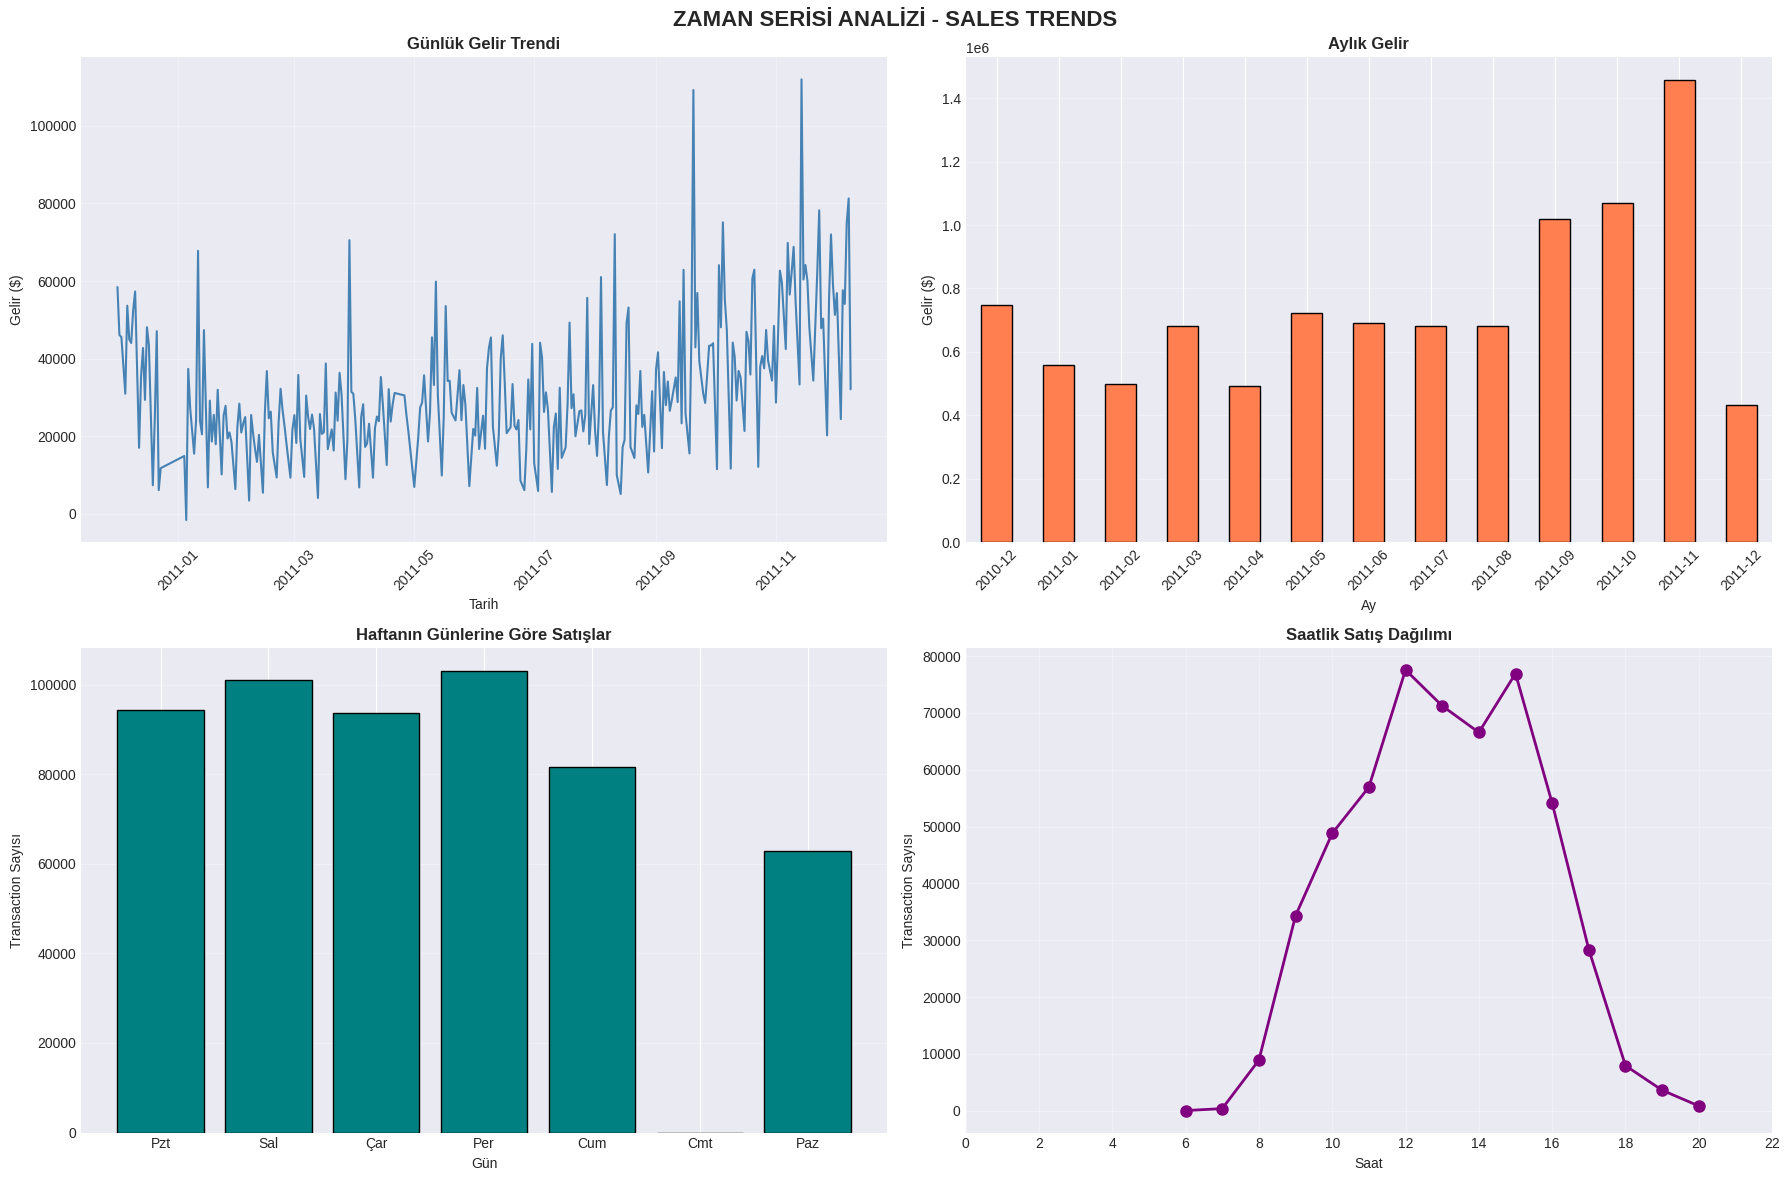

In [15]:
# Tarih sütununu bul
date_col = None
for col in df.columns:
    if df[col].dtype == 'datetime64[ns]':
        date_col = col
        break

if date_col:
    print(f"{'='*80}")
    print(f"📈 ZAMAN SERİSİ ANALİZİ ({date_col})")
    print(f"{'='*80}\n")

    # Tarih aralığı
    min_date = df[date_col].min()
    max_date = df[date_col].max()
    date_range = (max_date - min_date).days

    print(f"📅 İlk Transaction: {min_date}")
    print(f"📅 Son Transaction: {max_date}")
    print(f"📊 Toplam Süre: {date_range} gün ({date_range/30:.1f} ay)")

    # Zaman özellikleri ekle
    df['Year'] = df[date_col].dt.year
    df['Month'] = df[date_col].dt.month
    df['Day'] = df[date_col].dt.day
    df['DayOfWeek'] = df[date_col].dt.dayofweek
    df['Hour'] = df[date_col].dt.hour
    df['Quarter'] = df[date_col].dt.quarter
    df['YearMonth'] = df[date_col].dt.to_period('M')

    print("\n✅ Zaman özellikleri eklendi: Year, Month, Day, DayOfWeek, Hour, Quarter, YearMonth")

    # Günlük satış trendi
    daily_sales = df.groupby(df[date_col].dt.date).agg({
        'InvoiceNo': 'nunique' if 'InvoiceNo' in df.columns else 'count',
        'TotalAmount': 'sum' if 'TotalAmount' in df.columns else 'count'
    })

    # Görselleştirme
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('ZAMAN SERİSİ ANALİZİ - SALES TRENDS', fontsize=16, fontweight='bold')

    # Günlük satış
    if 'TotalAmount' in df.columns:
        axes[0, 0].plot(daily_sales.index, daily_sales['TotalAmount'],
                       color='steelblue', linewidth=1.5)
        axes[0, 0].set_title('Günlük Gelir Trendi', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Tarih')
        axes[0, 0].set_ylabel('Gelir ($)')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].tick_params(axis='x', rotation=45)

    # Aylık trend
    if 'YearMonth' in df.columns and 'TotalAmount' in df.columns:
        monthly_revenue = df.groupby('YearMonth')['TotalAmount'].sum()
        monthly_revenue.plot(ax=axes[0, 1], kind='bar', color='coral', edgecolor='black')
        axes[0, 1].set_title('Aylık Gelir', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Ay')
        axes[0, 1].set_ylabel('Gelir ($)')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        axes[0, 1].tick_params(axis='x', rotation=45)

    # Gün bazında satışlar
    if 'DayOfWeek' in df.columns:
        day_names = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
        day_sales = df.groupby('DayOfWeek').size()
        axes[1, 0].bar(range(7), [day_sales.get(i, 0) for i in range(7)],
                      color='teal', edgecolor='black')
        axes[1, 0].set_xticks(range(7))
        axes[1, 0].set_xticklabels(day_names)
        axes[1, 0].set_title('Haftanın Günlerine Göre Satışlar', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Gün')
        axes[1, 0].set_ylabel('Transaction Sayısı')
        axes[1, 0].grid(True, alpha=0.3, axis='y')

    # Saatlik satışlar
    if 'Hour' in df.columns:
        hourly_sales = df.groupby('Hour').size()
        axes[1, 1].plot(hourly_sales.index, hourly_sales.values,
                       marker='o', color='purple', linewidth=2, markersize=8)
        axes[1, 1].set_title('Saatlik Satış Dağılımı', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Saat')
        axes[1, 1].set_ylabel('Transaction Sayısı')
        axes[1, 1].set_xticks(range(0, 24, 2))
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Tarih sütunu bulunamadı!")

### 7.3 Ürün Analizi

🏷️ ÜRÜN PERFORMANS ANALİZİ

📊 EN ÇOK SATAN 20 ÜRÜN:
--------------------------------------------------------------------------------


,Toplam_Adet,Toplam_Gelir,Sipariş_Sayısı
Description,,,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751,13560.09,540
JUMBO BAG RED RETROSPOT,47260,92175.79,2135
POPCORN HOLDER,36322,33959.26,839
ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42,1467
PACK OF 72 RETROSPOT CAKE CASES,36016,21047.07,1334
WHITE HANGING HEART T-LIGHT HOLDER,35298,99612.42,2302
RABBIT NIGHT LIGHT,30631,66661.63,1009
MINI PAINT SET VINTAGE,26437,16810.42,390
PACK OF 12 LONDON TISSUES,26299,7967.82,515


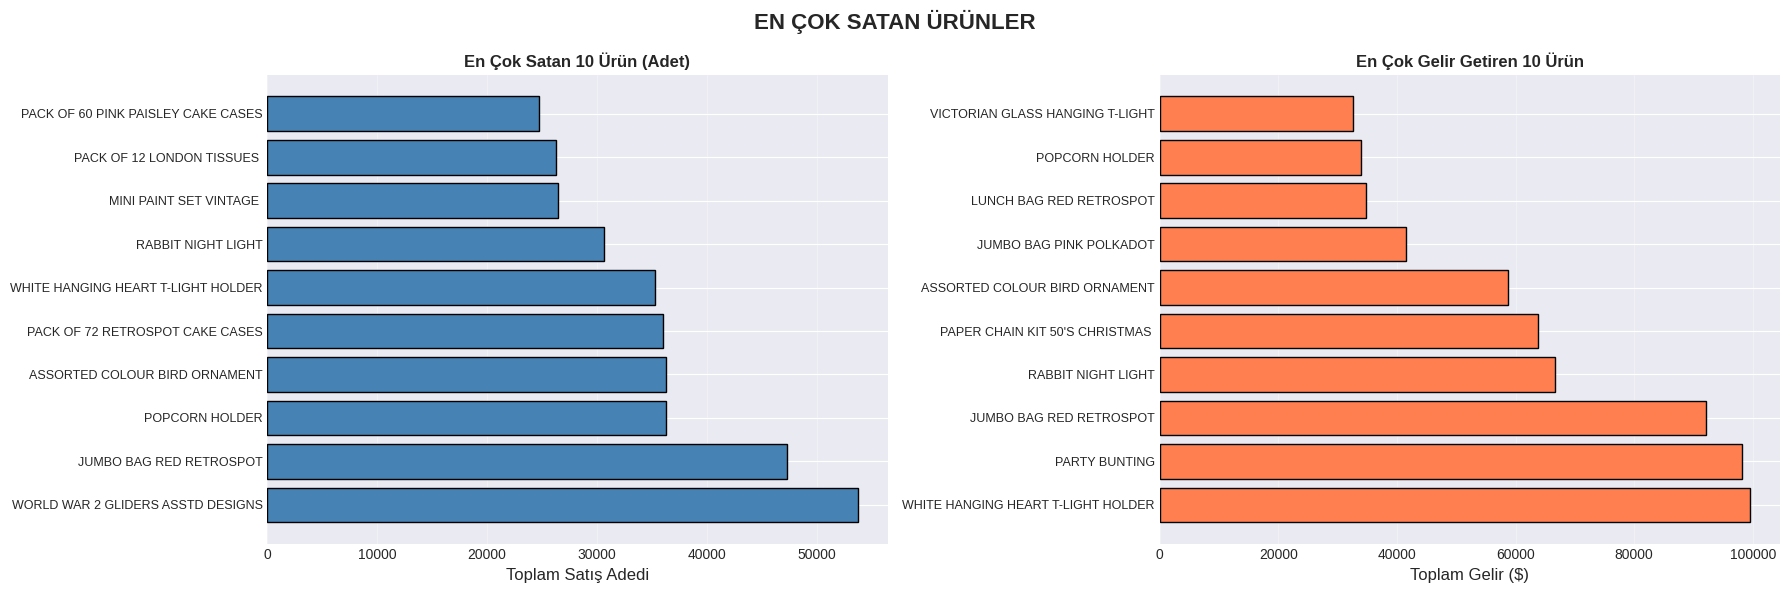

In [16]:
if 'Description' in df.columns or 'StockCode' in df.columns:
    print(f"{'='*80}")
    print("🏷️ ÜRÜN PERFORMANS ANALİZİ")
    print(f"{'='*80}\n")

    # En çok satılan ürünler
    if 'Description' in df.columns and 'Quantity' in df.columns:
        product_sales = df.groupby('Description').agg({
            'Quantity': 'sum',
            'TotalAmount': 'sum' if 'TotalAmount' in df.columns else 'count',
            'InvoiceNo': 'nunique' if 'InvoiceNo' in df.columns else 'count'
        }).sort_values('Quantity', ascending=False).head(20)

        product_sales.columns = ['Toplam_Adet', 'Toplam_Gelir', 'Sipariş_Sayısı']

        print("📊 EN ÇOK SATAN 20 ÜRÜN:")
        print("-" * 80)
        display(product_sales)

        # Görselleştirme
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle('EN ÇOK SATAN ÜRÜNLER', fontsize=16, fontweight='bold')

        # Top 10 by quantity
        top_10_qty = product_sales.head(10)
        axes[0].barh(range(10), top_10_qty['Toplam_Adet'], color='steelblue', edgecolor='black')
        axes[0].set_yticks(range(10))
        axes[0].set_yticklabels([desc[:40] for desc in top_10_qty.index], fontsize=9)
        axes[0].set_xlabel('Toplam Satış Adedi', fontsize=12)
        axes[0].set_title('En Çok Satan 10 Ürün (Adet)', fontsize=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3, axis='x')

        # Top 10 by revenue
        if 'TotalAmount' in df.columns:
            top_10_rev = product_sales.sort_values('Toplam_Gelir', ascending=False).head(10)
            axes[1].barh(range(10), top_10_rev['Toplam_Gelir'], color='coral', edgecolor='black')
            axes[1].set_yticks(range(10))
            axes[1].set_yticklabels([desc[:40] for desc in top_10_rev.index], fontsize=9)
            axes[1].set_xlabel('Toplam Gelir ($)', fontsize=12)
            axes[1].set_title('En Çok Gelir Getiren 10 Ürün', fontsize=12, fontweight='bold')
            axes[1].grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.show()

### 7.4 Müşteri Analizi

👥 MÜŞTERİ ANALİZİ

📊 MÜŞTERİ İSTATİSTİKLERİ:
--------------------------------------------------------------------------------
       Sipariş_Sayısı  Toplam_Harcama                  Son_Alışveriş  \
count         4372.00         4372.00                           4372   
mean             5.08         1893.53  2011-09-08 23:12:06.697163520   
min              1.00        -4287.63            2010-12-01 09:53:00   
25%              1.00          291.80            2011-07-19 15:21:30   
50%              3.00          644.07            2011-10-20 15:56:30   
75%              5.00         1608.34            2011-11-23 09:29:30   
max            248.00       279489.02            2011-12-09 12:50:00   
std              9.34         8218.70                            NaN   

       Ortalama_Sipariş_Değeri  
count                  4372.00  
mean                    314.49  
min                   -4287.63  
25%                     151.43  
50%                     235.15  
75%                     366

,Sipariş_Sayısı,Toplam_Harcama,Son_Alışveriş,Ortalama_Sipariş_Değeri
CustomerID,,,,
14646.00,77,279489.02,2011-12-08 12:12:00,3629.73
18102.00,62,256438.49,2011-12-09 11:50:00,4136.10
17450.00,55,187322.17,2011-12-01 13:29:00,3405.86
14911.00,248,132458.73,2011-12-08 15:54:00,534.11
12415.00,26,123725.45,2011-11-15 14:22:00,4758.67
14156.00,66,113214.59,2011-11-30 10:54:00,1715.37
17511.00,46,88125.38,2011-12-07 10:12:00,1915.77
16684.00,31,65892.08,2011-12-05 14:06:00,2125.55
13694.00,60,62690.54,2011-12-06 09:32:00,1044.84


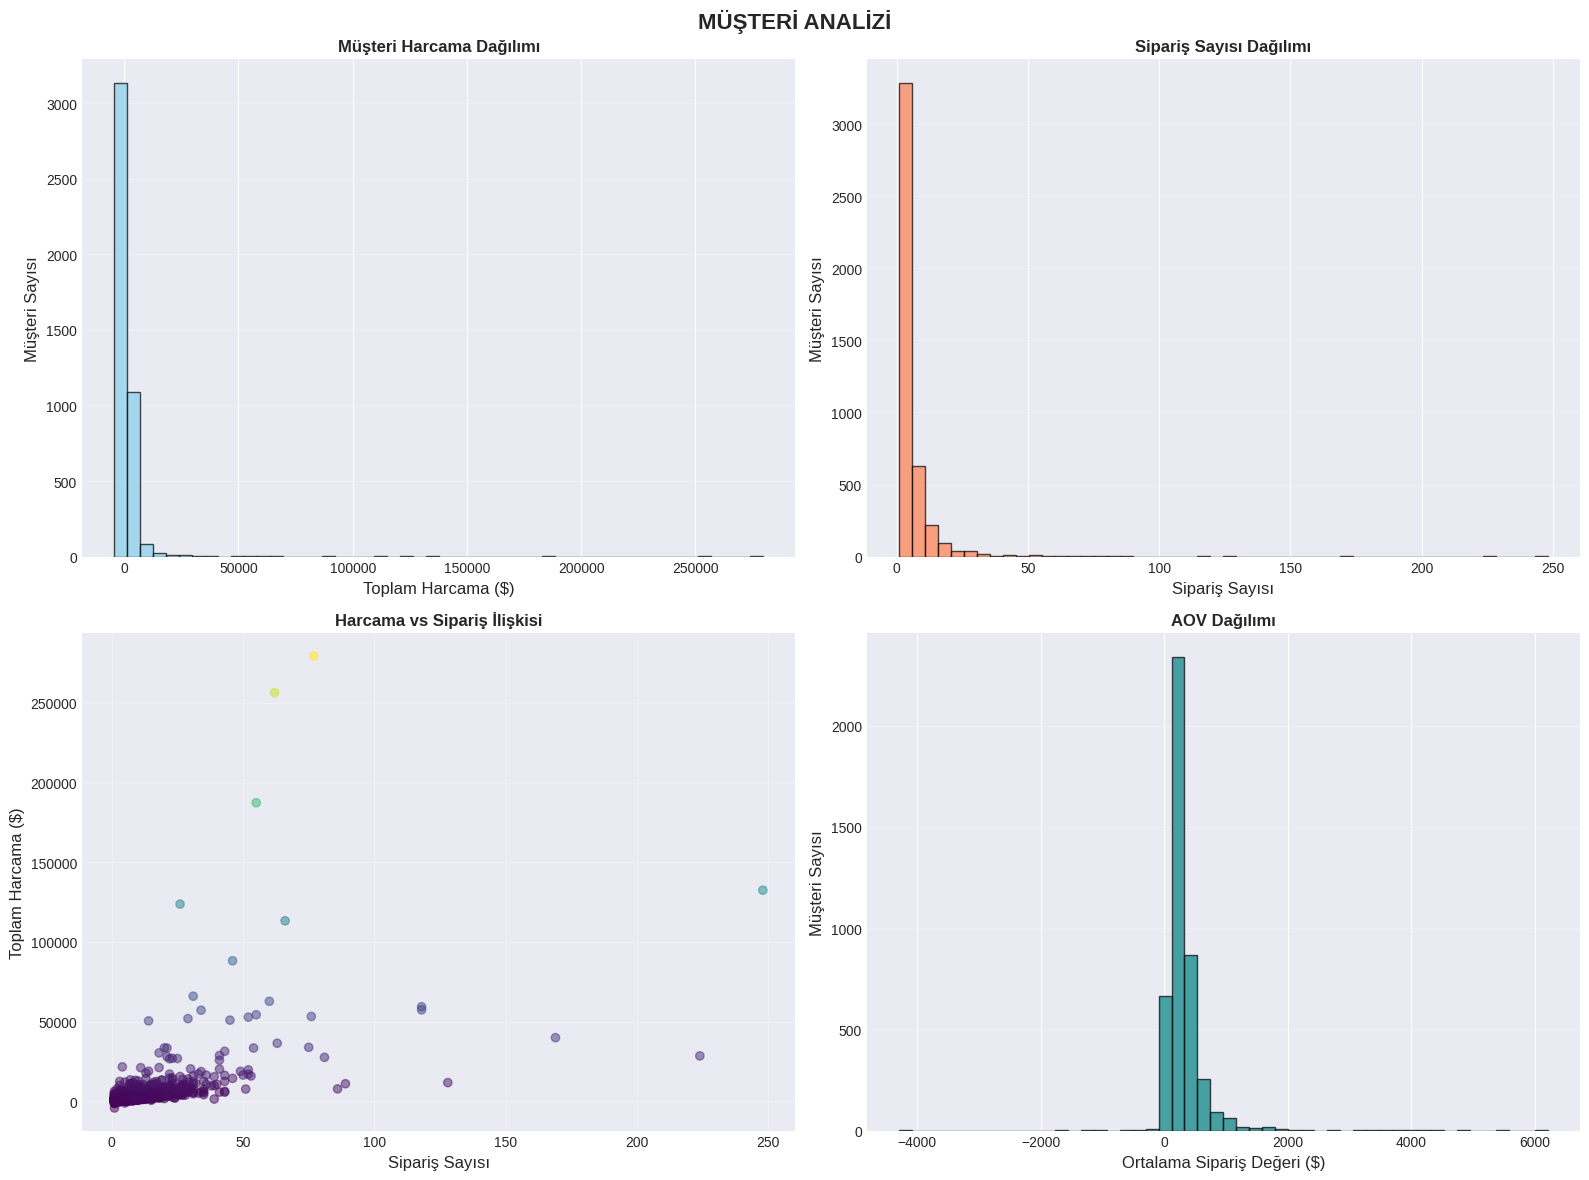

In [17]:
if 'CustomerID' in df.columns:
    print(f"{'='*80}")
    print("👥 MÜŞTERİ ANALİZİ")
    print(f"{'='*80}\n")

    df_customers = df[df['CustomerID'].notna()].copy()

    if 'TotalAmount' in df_customers.columns and 'InvoiceNo' in df_customers.columns:
        customer_analysis = df_customers.groupby('CustomerID').agg({
            'InvoiceNo': 'nunique',
            'TotalAmount': 'sum',
            date_col: 'max' if date_col else 'count'
        })

        customer_analysis.columns = ['Sipariş_Sayısı', 'Toplam_Harcama', 'Son_Alışveriş']
        customer_analysis['Ortalama_Sipariş_Değeri'] = (
            customer_analysis['Toplam_Harcama'] / customer_analysis['Sipariş_Sayısı']
        )

        print("📊 MÜŞTERİ İSTATİSTİKLERİ:")
        print("-" * 80)
        print(customer_analysis.describe())

        # En iyi müşteriler
        print(f"\n🏆 EN İYİ 10 MÜŞTERİ (Toplam Harcamaya Göre):")
        print("-" * 80)
        top_customers = customer_analysis.sort_values('Toplam_Harcama', ascending=False).head(10)
        display(top_customers)

        # Görselleştirme
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('MÜŞTERİ ANALİZİ', fontsize=16, fontweight='bold')

        # Toplam harcama dağılımı
        axes[0, 0].hist(customer_analysis['Toplam_Harcama'], bins=50,
                       color='skyblue', edgecolor='black', alpha=0.7)
        axes[0, 0].set_xlabel('Toplam Harcama ($)', fontsize=12)
        axes[0, 0].set_ylabel('Müşteri Sayısı', fontsize=12)
        axes[0, 0].set_title('Müşteri Harcama Dağılımı', fontsize=12, fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3, axis='y')

        # Sipariş sayısı dağılımı
        axes[0, 1].hist(customer_analysis['Sipariş_Sayısı'], bins=50,
                       color='coral', edgecolor='black', alpha=0.7)
        axes[0, 1].set_xlabel('Sipariş Sayısı', fontsize=12)
        axes[0, 1].set_ylabel('Müşteri Sayısı', fontsize=12)
        axes[0, 1].set_title('Sipariş Sayısı Dağılımı', fontsize=12, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='y')

        # Harcama vs Sipariş sayısı
        axes[1, 0].scatter(customer_analysis['Sipariş_Sayısı'],
                          customer_analysis['Toplam_Harcama'],
                          alpha=0.5, c=customer_analysis['Toplam_Harcama'],
                          cmap='viridis')
        axes[1, 0].set_xlabel('Sipariş Sayısı', fontsize=12)
        axes[1, 0].set_ylabel('Toplam Harcama ($)', fontsize=12)
        axes[1, 0].set_title('Harcama vs Sipariş İlişkisi', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)

        # Ortalama sipariş değeri
        axes[1, 1].hist(customer_analysis['Ortalama_Sipariş_Değeri'], bins=50,
                       color='teal', edgecolor='black', alpha=0.7)
        axes[1, 1].set_xlabel('Ortalama Sipariş Değeri ($)', fontsize=12)
        axes[1, 1].set_ylabel('Müşteri Sayısı', fontsize=12)
        axes[1, 1].set_title('AOV Dağılımı', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

### 7.5 Coğrafi Analiz

🌍 COĞRAFİ ANALİZ

📊 EN ÇOK GELİR GETİREN 15 ÜLKE:
--------------------------------------------------------------------------------


,Sipariş_Sayısı,Müşteri_Sayısı,Toplam_Gelir
Country,,,
United Kingdom,23494,3950,8167128.18
Netherlands,101,9,284661.54
EIRE,360,3,262993.38
Germany,603,95,221509.47
France,461,87,197317.11
Australia,69,9,137009.77
Switzerland,74,21,56363.05
Spain,105,31,54756.03
Belgium,119,25,40910.96


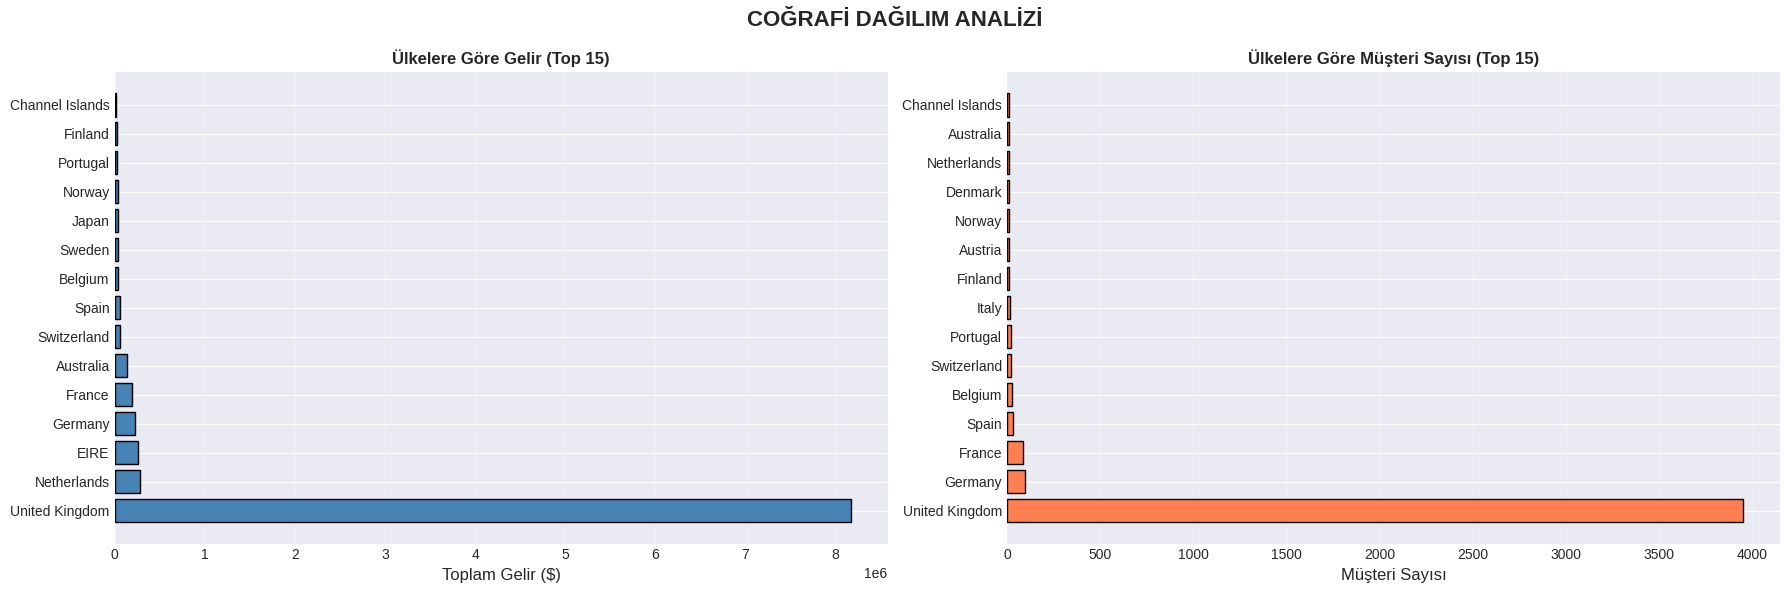

In [18]:
if 'Country' in df.columns:
    print(f"{'='*80}")
    print("🌍 COĞRAFİ ANALİZ")
    print(f"{'='*80}\n")

    country_analysis = df.groupby('Country').agg({
        'InvoiceNo': 'nunique' if 'InvoiceNo' in df.columns else 'count',
        'CustomerID': 'nunique' if 'CustomerID' in df.columns else 'count',
        'TotalAmount': 'sum' if 'TotalAmount' in df.columns else 'count'
    }).sort_values('TotalAmount' if 'TotalAmount' in df.columns else 'InvoiceNo',
                   ascending=False)

    country_analysis.columns = ['Sipariş_Sayısı', 'Müşteri_Sayısı', 'Toplam_Gelir']

    print("📊 EN ÇOK GELİR GETİREN 15 ÜLKE:")
    print("-" * 80)
    display(country_analysis.head(15))

    # Görselleştirme
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('COĞRAFİ DAĞILIM ANALİZİ', fontsize=16, fontweight='bold')

    # Top 15 ülke - gelir
    top_15 = country_analysis.head(15)
    axes[0].barh(range(15), top_15['Toplam_Gelir'], color='steelblue', edgecolor='black')
    axes[0].set_yticks(range(15))
    axes[0].set_yticklabels(top_15.index, fontsize=10)
    axes[0].set_xlabel('Toplam Gelir ($)', fontsize=12)
    axes[0].set_title('Ülkelere Göre Gelir (Top 15)', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')

    # Top 15 ülke - müşteri sayısı
    top_15_customers = country_analysis.sort_values('Müşteri_Sayısı', ascending=False).head(15)
    axes[1].barh(range(15), top_15_customers['Müşteri_Sayısı'], color='coral', edgecolor='black')
    axes[1].set_yticks(range(15))
    axes[1].set_yticklabels(top_15_customers.index, fontsize=10)
    axes[1].set_xlabel('Müşteri Sayısı', fontsize=12)
    axes[1].set_title('Ülkelere Göre Müşteri Sayısı (Top 15)', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

### 7.6 RFM Analizi (Recency, Frequency, Monetary)

💎 RFM ANALİZİ (Recency, Frequency, Monetary)

📊 RFM İSTATİSTİKLERİ:
--------------------------------------------------------------------------------
       Recency  Frequency  Monetary
count  4372.00    4372.00   4372.00
mean     92.05       5.08   1893.53
std     100.77       9.34   8218.70
min       1.00       1.00  -4287.63
25%      17.00       1.00    291.80
50%      50.00       3.00    644.07
75%     143.00       5.00   1608.34
max     374.00     248.00 279489.02

🎯 MÜŞTERİ SEGMENTASYONU:
--------------------------------------------------------------------------------


,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count
Segment,,,,
Potential,81.72,2.31,624.85,1115
Loyal,43.19,4.62,1385.43,991
Champions,13.49,14.12,6205.02,947
At Risk,150.77,1.40,314.76,782
Lost,256.67,1.05,161.19,537


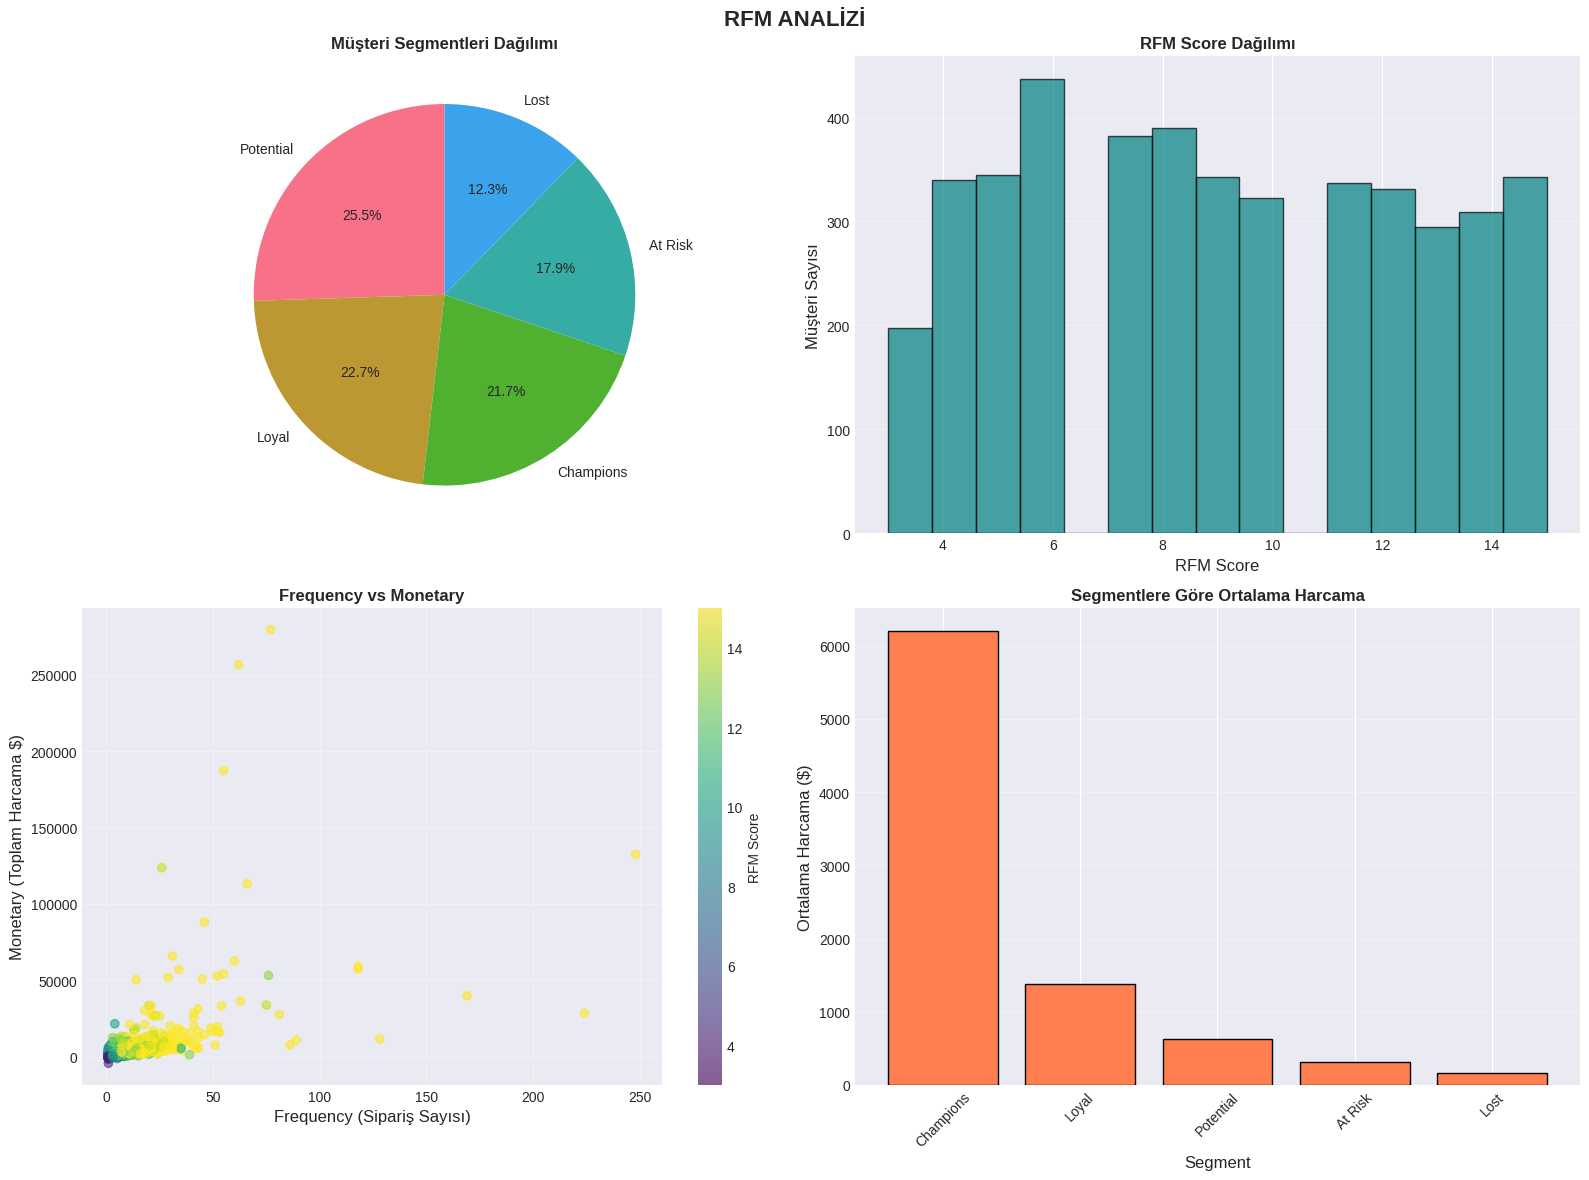


✅ RFM analizi tamamlandı ve 'rfm' değişkenine kaydedildi


In [19]:
if 'CustomerID' in df.columns and date_col and 'TotalAmount' in df.columns:
    print(f"{'='*80}")
    print("💎 RFM ANALİZİ (Recency, Frequency, Monetary)")
    print(f"{'='*80}\n")

    df_rfm = df[df['CustomerID'].notna()].copy()

    # Referans tarih (son tarih + 1 gün)
    reference_date = df_rfm[date_col].max() + timedelta(days=1)

    # RFM hesapla
    rfm = df_rfm.groupby('CustomerID').agg({
        date_col: lambda x: (reference_date - x.max()).days,  # Recency
        'InvoiceNo': 'nunique',  # Frequency
        'TotalAmount': 'sum'  # Monetary
    })

    rfm.columns = ['Recency', 'Frequency', 'Monetary']

    # RFM skorları (1-5 arası)
    rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
    rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

    # Toplam RFM skoru
    rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

    # Segment oluştur
    def rfm_segment(row):
        if row['RFM_Score'] >= 13:
            return 'Champions'
        elif row['RFM_Score'] >= 10:
            return 'Loyal'
        elif row['RFM_Score'] >= 7:
            return 'Potential'
        elif row['RFM_Score'] >= 5:
            return 'At Risk'
        else:
            return 'Lost'

    rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

    print("📊 RFM İSTATİSTİKLERİ:")
    print("-" * 80)
    print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

    print(f"\n🎯 MÜŞTERİ SEGMENTASYONU:")
    print("-" * 80)
    segment_summary = rfm.groupby('Segment').agg({
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': ['mean', 'count']
    }).round(2)
    segment_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
    display(segment_summary.sort_values('Customer_Count', ascending=False))

    # Görselleştirme
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('RFM ANALİZİ', fontsize=16, fontweight='bold')

    # Segment dağılımı
    segment_counts = rfm['Segment'].value_counts()
    axes[0, 0].pie(segment_counts.values, labels=segment_counts.index,
                   autopct='%1.1f%%', startangle=90)
    axes[0, 0].set_title('Müşteri Segmentleri Dağılımı', fontsize=12, fontweight='bold')

    # RFM score dağılımı
    axes[0, 1].hist(rfm['RFM_Score'], bins=15, color='teal', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('RFM Score', fontsize=12)
    axes[0, 1].set_ylabel('Müşteri Sayısı', fontsize=12)
    axes[0, 1].set_title('RFM Score Dağılımı', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # Frequency vs Monetary
    scatter = axes[1, 0].scatter(rfm['Frequency'], rfm['Monetary'],
                                c=rfm['RFM_Score'], cmap='viridis', alpha=0.6)
    axes[1, 0].set_xlabel('Frequency (Sipariş Sayısı)', fontsize=12)
    axes[1, 0].set_ylabel('Monetary (Toplam Harcama $)', fontsize=12)
    axes[1, 0].set_title('Frequency vs Monetary', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, 0], label='RFM Score')

    # Segment bazında ortalama monetary
    segment_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
    axes[1, 1].bar(segment_monetary.index, segment_monetary.values,
                  color='coral', edgecolor='black')
    axes[1, 1].set_xlabel('Segment', fontsize=12)
    axes[1, 1].set_ylabel('Ortalama Harcama ($)', fontsize=12)
    axes[1, 1].set_title('Segmentlere Göre Ortalama Harcama', fontsize=12, fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # RFM'i ana dataframe'e ekle
    print("\n✅ RFM analizi tamamlandı ve 'rfm' değişkenine kaydedildi")

## 📊 8. FINAL SUMMARY & BUSINESS INSIGHTS

In [20]:
print(f"{'='*80}")
print("🎯 E-COMMERCE ANALİZ ÖZETİ")
print(f"{'='*80}\n")

print("✅ TAMAMLANAN ANALİZLER:")
print("  1. ✓ Dataset İndirme (Wget ile direkt Kaggle)")
print("  2. ✓ Veri Yükleme ve İlk Keşif")
print("  3. ✓ Veri Kalitesi Analizi (Missing, Duplicates)")
print("  4. ✓ Veri Temizleme ve Önişleme")
print("  5. ✓ Tanımlayıcı İstatistikler")
print("  6. ✓ E-Commerce Temel Metrikleri")
print("  7. ✓ Zaman Serisi Analizi (Sales Trends)")
print("  8. ✓ Ürün Performans Analizi")
print("  9. ✓ Müşteri Analizi")
print(" 10. ✓ Coğrafi Analiz")
print(" 11. ✓ RFM Analizi (Customer Segmentation)")

print(f"\n🏆 KEY FINDINGS:")
print(f"  • Dataset Boyutu: {df.shape[0]:,} transaction x {df.shape[1]} sütun")

if 'InvoiceNo' in df.columns:
    print(f"  • Toplam Sipariş: {df['InvoiceNo'].nunique():,}")

if 'CustomerID' in df.columns:
    df_with_cust = df[df['CustomerID'].notna()]
    print(f"  • Toplam Müşteri: {df_with_cust['CustomerID'].nunique():,}")

if 'TotalAmount' in df.columns:
    print(f"  • Toplam Gelir: ${df['TotalAmount'].sum():,.2f}")
    print(f"  • Ortalama Transaction: ${df['TotalAmount'].mean():.2f}")

if 'Country' in df.columns:
    top_country = df.groupby('Country')['TotalAmount'].sum().idxmax()
    print(f"  • En Çok Gelir Getiren Ülke: {top_country}")

print(f"\n💡 İŞ ÖNERİLERİ:")
print("  1. 📈 Champions ve Loyal müşterilere VIP programlar sunun")
print("  2. 🎯 At Risk müşterilere win-back kampanyaları düzenleyin")
print("  3. 📦 En çok satan ürünlerin stok yönetimini optimize edin")
print("  4. 🌍 Yüksek gelirli ülkelerde marketing yatırımını artırın")
print("  5. ⏰ Yoğun saatlere göre operasyonel kaynakları planlayın")
print("  6. 📊 Düşük AOV müşterilere cross-sell/up-sell stratejileri geliştirin")

print(f"\n{'='*80}")
print("✅ E-COMMERCE DATA SCIENCE ANALİZİ TAMAMLANDI!")
print(f"{'='*80}")
print("\n🎉 Başarıyla Tamamlandı!")
print("\n📝 Bu analiz şunları içerdi:")
print("   • Wget ile Kaggle dataset indirme")
print("   • E-commerce'e özel metrikler")
print("   • RFM analizi ve müşteri segmentasyonu")
print("   • Zaman serisi ve trend analizi")
print("   • Ürün ve coğrafi performans analizi")
print("   • Actionable business insights")

🎯 E-COMMERCE ANALİZ ÖZETİ

✅ TAMAMLANAN ANALİZLER:
  1. ✓ Dataset İndirme (Wget ile direkt Kaggle)
  2. ✓ Veri Yükleme ve İlk Keşif
  3. ✓ Veri Kalitesi Analizi (Missing, Duplicates)
  4. ✓ Veri Temizleme ve Önişleme
  5. ✓ Tanımlayıcı İstatistikler
  6. ✓ E-Commerce Temel Metrikleri
  7. ✓ Zaman Serisi Analizi (Sales Trends)
  8. ✓ Ürün Performans Analizi
  9. ✓ Müşteri Analizi
 10. ✓ Coğrafi Analiz
 11. ✓ RFM Analizi (Customer Segmentation)

🏆 KEY FINDINGS:
  • Dataset Boyutu: 536,641 transaction x 16 sütun
  • Toplam Sipariş: 25,900
  • Toplam Müşteri: 4,372
  • Toplam Gelir: $9,726,006.95
  • Ortalama Transaction: $18.12
  • En Çok Gelir Getiren Ülke: United Kingdom

💡 İŞ ÖNERİLERİ:
  1. 📈 Champions ve Loyal müşterilere VIP programlar sunun
  2. 🎯 At Risk müşterilere win-back kampanyaları düzenleyin
  3. 📦 En çok satan ürünlerin stok yönetimini optimize edin
  4. 🌍 Yüksek gelirli ülkelerde marketing yatırımını artırın
  5. ⏰ Yoğun saatlere göre operasyonel kaynakları planlayın
  6.